# ✈️ Flight Delay Prediction — End-to-End Project

## Problem Statement

Flight delays cost the U.S. airline industry **\$33 billion per year** and directly affect passenger experience, crew scheduling, and airport operations. The ability to predict whether a flight will be significantly delayed (>15 minutes) before it departs enables:

- **Airlines** to proactively re-accommodate passengers and reassign crew.
- **Airports** to optimise gate and ground resource allocation.
- **Passengers** to make informed re-booking decisions.

### Objective
Build a binary classification model that predicts whether a scheduled flight will arrive **more than 15 minutes late** (`ArrDel15 = 1`), using only information available **at the time of scheduling** (no post-departure leakage).

### Dataset
U.S. Bureau of Transportation Statistics (BTS) On-Time Performance data — domestic scheduled flights, 2024 Q1 (~11,600 records, 120 raw features).

### Key Questions
1. Which airlines, airports, and routes are most delay-prone?
2. Do time-of-day, day-of-week, and seasonal patterns predict delays?
3. What operational features (taxi time, aircraft rotation, route distance) matter most?
4. Which model best balances recall vs. precision for business use?


---
## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("Libraries loaded")

Libraries loaded


In [ ]:
df = pd.read_csv('flight_data_2018_2024.csv')
print(f"Dataset shape: {df.shape}")
df.sample(3)

Dataset shape: (582425, 120)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
286681,2024,1,1,28,7,2024-01-28,NK,NK,20416,NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
538532,2024,1,1,11,4,2024-01-11,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
261632,2024,1,1,8,1,2024-01-08,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


---
## 2. Data Understanding

We begin with a structured audit of columns, types, and basic statistics.


In [ ]:
# column overview
print(f"Columns : {df.shape[1]}")
print(f"Rows    : {df.shape[0]}")
print()
df.info(verbose=True, show_counts=True)


Columns : 120
Rows    : 582,425

<class 'pandas.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Data columns (total 120 columns):
 #    Column                                              Non-Null Count   Dtype  
---   ------                                              --------------   -----  
 0    Year                                                582425 non-null  int64  
 1    Quarter                                             582425 non-null  int64  
 2    Month                                               582425 non-null  int64  
 3    DayofMonth                                          582425 non-null  int64  
 4    DayOfWeek                                           582425 non-null  int64  
 5    FlightDate                                          582425 non-null  str    
 6    Marketing_Airline_Network                           582425 non-null  str    
 7    Operated_or_Branded_Code_Share_Partners             582425 non-null  str    
 8    DOT_ID_Marketing_Airline      

In [ ]:
# descriptive statistics for important numeric columns
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'TaxiOut', 'TaxiIn',
            'AirTime', 'CRSElapsedTime', 'CarrierDelay',
            'WeatherDelay', 'NASDelay', 'LateAircraftDelay']
df[key_cols].describe().round(2)

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn,AirTime,CRSElapsedTime,CarrierDelay,WeatherDelay,NASDelay,LateAircraftDelay
count,560955.00,558715.00,582425.00,560515.00,560093.00,558715.00,582425.00,134575.00,134575.00,134575.00,134575.00
mean,15.97,10.66,809.34,18.98,8.28,113.29,146.07,24.64,8.02,13.52,30.58
std,66.06,68.65,588.76,11.51,6.95,70.21,72.41,80.81,52.31,30.15,68.25
min,-56.00,-90.00,31.00,1.00,1.00,7.00,26.00,0.00,0.00,0.00,0.00
25%,-6.00,-16.00,377.00,12.00,4.00,62.00,93.00,0.00,0.00,0.00,0.00
50%,-2.00,-5.00,661.00,16.00,6.00,96.00,130.00,2.00,0.00,1.00,1.00
75%,12.00,13.00,1050.00,22.00,10.00,144.00,177.00,21.00,0.00,18.00,35.00
max,3125.00,3136.00,5095.00,213.00,444.00,1338.00,690.00,2972.00,1804.00,1431.00,1741.00


In [ ]:
# missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})

,Missing Count,Missing %
Unnamed: 119,582425,100.0
Div5Airport,582425,100.0
Div4AirportID,582425,100.0
Div4AirportSeqID,582425,100.0
Div4WheelsOn,582425,100.0
...,...,...
DepDel15,21470,3.7
DepDelayMinutes,21470,3.7
DepDelay,21470,3.7
DepTime,21396,3.7


- CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay are 77% null — only populated for delayed flights.
- They are valuable for EDA but can't be used as model features (target leakage).
- ArrDelay / DepDelay are ~4% null — cancelled or diverted flights.
- Diversion kind of columns are >99% null and will be dropped.


---
## 3. Data Cleaning


In [ ]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Year']       = df['FlightDate'].dt.year
df['Month']      = df['FlightDate'].dt.month
df['DayofMonth'] = df['FlightDate'].dt.day
df['DayOfWeek']  = df['FlightDate'].dt.dayofweek   # 0=Mon ... 6=Sun

# drop near-empty diverted-leg columns (>95% na valuews)
div_cols = [c for c in df.columns if c.startswith('Div') and c != 'Diverted']
df.drop(columns=div_cols + ['Unnamed: 119'], errors='ignore', inplace=True)

# filter to non-cancelled flights
df_model = df[df['Cancelled'] == 0].copy()
df_model.dropna(subset=['ArrDelay', 'DepDelay'], inplace=True)

# ceate binary target: Arrived >15 min late
df_model['ArrDel15'] = (df_model['ArrDelay'] > 15).astype(int)

print(f"Rows after cleaning : {len(df_model):,}")
print(f"Delayed (>15 min)   : {df_model['ArrDel15'].sum():,}  "f"({df_model['ArrDel15'].mean()*100:.1f}%)")
print(f"On-time             : {(df_model['ArrDel15']==0).sum():,}  "f"({(1-df_model['ArrDel15'].mean())*100:.1f}%)")


Rows after cleaning : 558,715
Delayed (>15 min)   : 130,480  (23.4%)
On-time             : 428,235  (76.6%)


In [ ]:
# leakage check: columns only known after the departure of flight 
leakage_cols = ['ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
                'DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups',
                'CarrierDelay', 'WeatherDelay', 'NASDelay',
                'SecurityDelay', 'LateAircraftDelay',
                'DepDel15', 'ArrTime', 'WheelsOff', 'WheelsOn',
                'ActualElapsedTime', 'AirTime', 'TaxiIn',
                'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime']

print("total leakage columns :", len(leakage_cols))
# these will be excluded from the feature matrix X


Leakage columns identified: 21
These will be excluded from the feature matrix X.


---
## 4. Exploratory Data Analysis

We keep **9 high-value visualisations** that each answer a distinct  question.

### Plot 1 — Arrival Delay Distribution & Class Balance

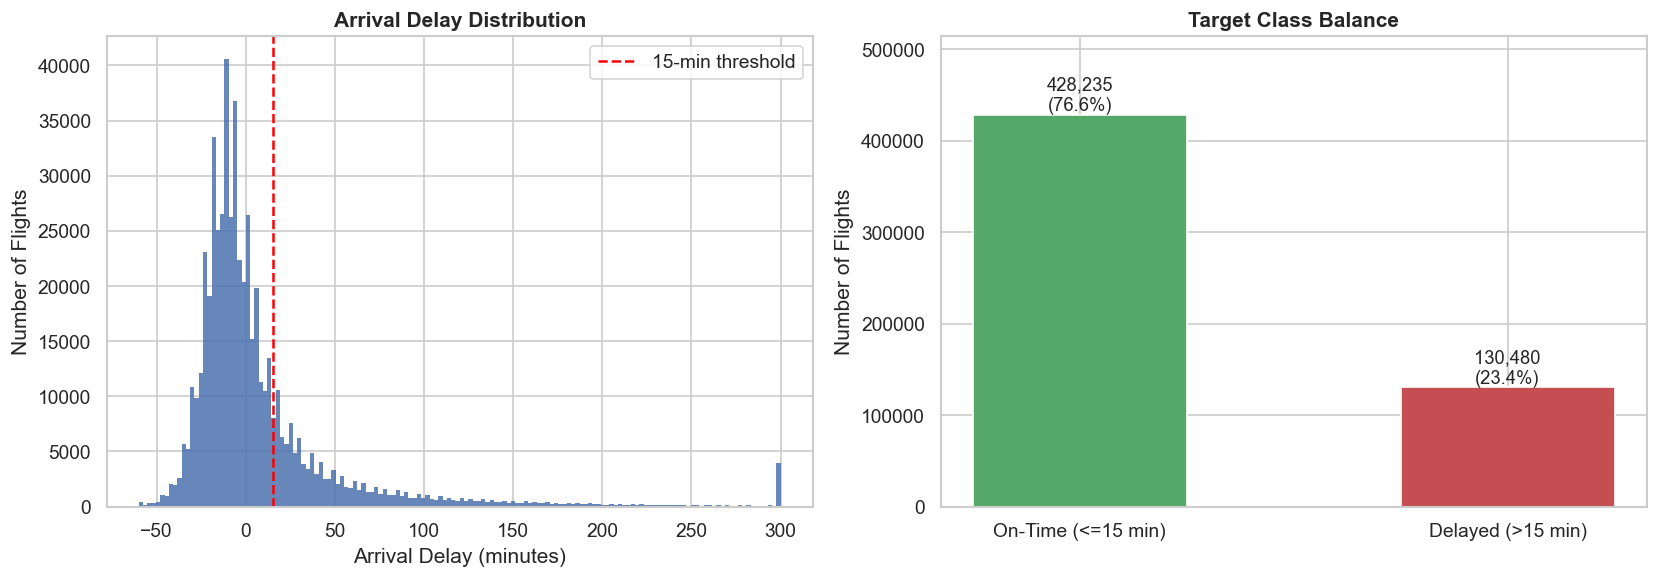

Business insight: ~76% of flights arrive on-time; 24% are delayed.
This mild imbalance warrants class_weight='balanced' during modelling.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution clipped at 300 min
ax = axes[0]
data = df_model['ArrDelay'].clip(-60, 300)
ax.hist(data, bins=150, color='#4C72B0', edgecolor='none', alpha=0.85)
ax.axvline(15, color='red', linestyle='--', linewidth=1.5, label='15-min threshold')
ax.set_title('Arrival Delay Distribution', fontweight='bold')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Number of Flights')
ax.legend()

#class balance
ax2 = axes[1]
counts = df_model['ArrDel15'].value_counts().sort_index()
bars = ax2.bar(['On-Time (<=15 min)', 'Delayed (>15 min)'],
               counts.values,
               color=['#55A868', '#C44E52'], width=0.5)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df_model)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)
ax2.set_title('Target Class Balance', fontweight='bold')
ax2.set_ylabel('Number of Flights')
ax2.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()
print("Business insight: ~76% of flights arrive on-time; 24% are delayed.")
print("This mild imbalance warrants class_weight='balanced' during modelling.")


### Plot 2 — Delay Cause Breakdown by Airline

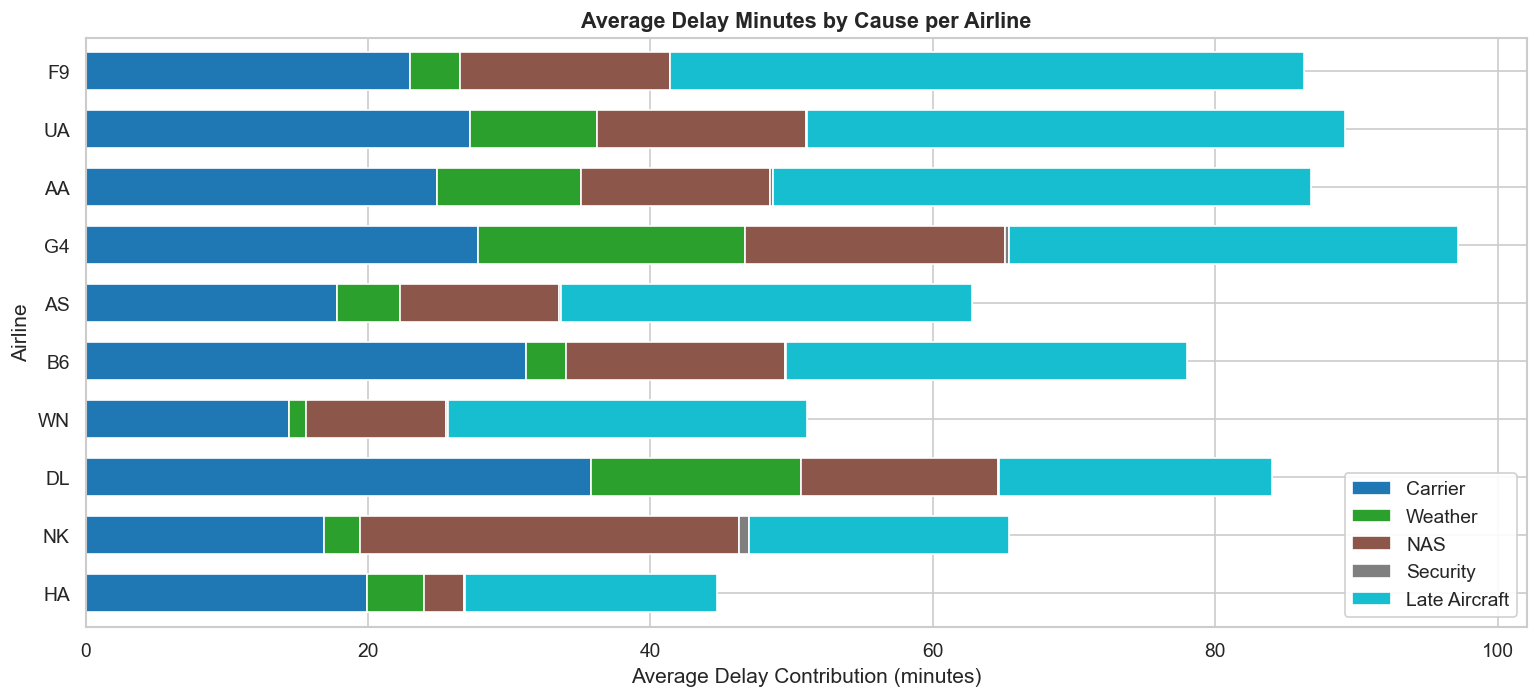

Business insight: Late-aircraft propagation dominates across all carriers.
Carriers with high Carrier share have controllable operational inefficiencies.


In [12]:
cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay',
              'SecurityDelay', 'LateAircraftDelay']
cause_cols = [c for c in cause_cols if c in df.columns]

cause_df = (df[cause_cols + ['Marketing_Airline_Network']]
            .dropna(subset=cause_cols, how='all')
            .groupby('Marketing_Airline_Network')[cause_cols]
            .mean()
            .round(1))

cause_df.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
cause_df.sort_values('Late Aircraft', ascending=True, inplace=True)

ax = cause_df.plot(kind='barh', stacked=True, figsize=(13, 6),
                   colormap='tab10', width=0.65)
ax.set_title('Average Delay Minutes by Cause per Airline', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Delay Contribution (minutes)')
ax.set_ylabel('Airline')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('plot2_delay_causes.png', bbox_inches='tight')
plt.show()
print("Business insight: Late-aircraft propagation dominates across all carriers.")
print("Carriers with high Carrier share have controllable operational inefficiencies.")


### Plot 3 — Seasonal Delay Heatmap (Airline x Month)

### Plot 4 — Delay Rate by Hour of Day

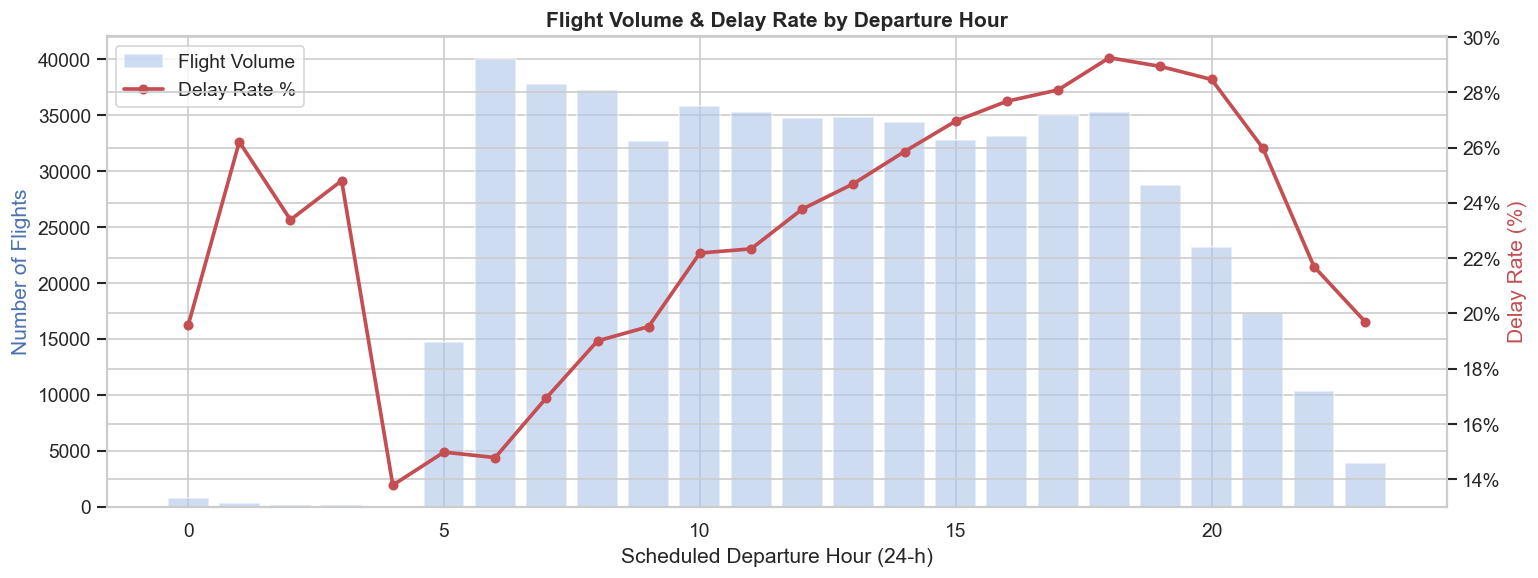

Business insight: Early-morning (5-7 AM) flights have the lowest delay rates.
Delay rates climb steadily peaking after 18:00 as cascade builds through the day.


In [14]:
df_model['DepHour'] = (df_model['CRSDepTime'] // 100).clip(0, 23)

hourly = (df_model.groupby('DepHour')['ArrDel15']
          .agg(['mean', 'count'])
          .reset_index())
hourly.columns = ['Hour', 'DelayRate', 'FlightCount']

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(hourly['Hour'], hourly['FlightCount'],
        color='#AEC6E8', alpha=0.6, width=0.8, label='Flight Volume')
ax2.plot(hourly['Hour'], hourly['DelayRate'] * 100,
         color='#C44E52', marker='o', linewidth=2.2, markersize=5,
         label='Delay Rate %')

ax1.set_xlabel('Scheduled Departure Hour (24-h)')
ax1.set_ylabel('Number of Flights', color='#4C72B0')
ax2.set_ylabel('Delay Rate (%)', color='#C44E52')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Flight Volume & Delay Rate by Departure Hour', fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_hourly_pattern.png', bbox_inches='tight')
plt.show()
print("Business insight: Early-morning (5-7 AM) flights have the lowest delay rates.")
print("Delay rates climb steadily peaking after 18:00 as cascade builds through the day.")


### Plot 5 — Delay Rate at Top 15 Busiest Origin Airports

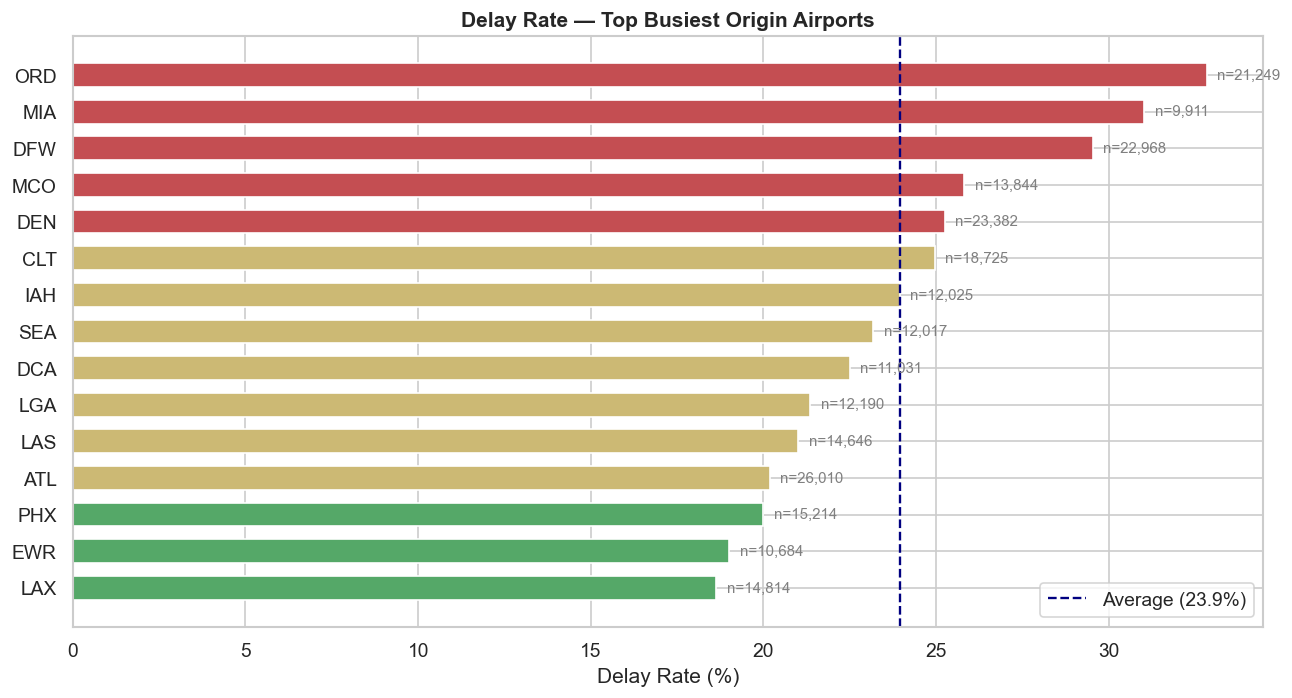

Business insight: High-volume hubs often show average or below-average delay rates
due to mature operations. Mid-size airports can have worse rates.


In [15]:
airport_stats = (df_model.groupby('Origin')
                 .agg(
                     DelayRate=('ArrDel15', 'mean'),
                     FlightCount=('ArrDel15', 'count')
                 )
                 .reset_index())

n_airports = min(15, len(airport_stats))
top_n = airport_stats.nlargest(n_airports, 'FlightCount').sort_values('DelayRate', ascending=True)
top_n['DelayRate_pct'] = top_n['DelayRate'] * 100

colors = ['#C44E52' if r > 25 else '#55A868' if r < 20 else '#CCB974'
          for r in top_n['DelayRate_pct']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_n['Origin'], top_n['DelayRate_pct'], color=colors, height=0.65)
ax.axvline(top_n['DelayRate_pct'].mean(), color='navy', linestyle='--',
           linewidth=1.4, label=f"Average ({top_n['DelayRate_pct'].mean():.1f}%)")
for bar, cnt in zip(bars, top_n['FlightCount']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'n={cnt:,}', va='center', fontsize=9, color='gray')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Delay Rate — Top Busiest Origin Airports', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot5_airport_delay.png', bbox_inches='tight')
plt.show()
print("Business insight: High-volume hubs often show average or below-average delay rates")
print("due to mature operations. Mid-size airports can have worse rates.")


### Plot 6 — Cancellation Rate by Airline & Root Cause

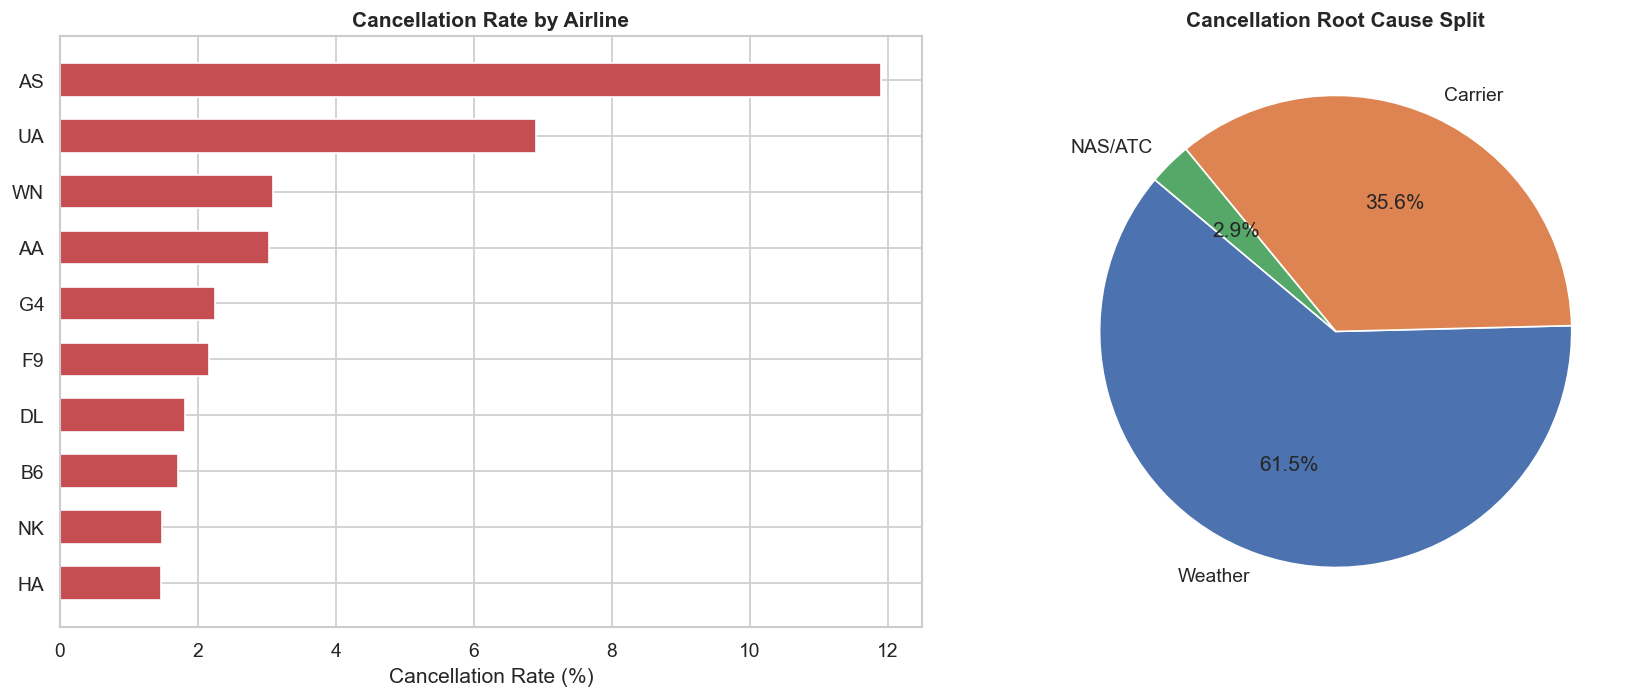

Business insight: Weather is the largest cancellation driver overall.
Carrier-related cancels highlight operational reliability differences.


In [16]:
cancel_df = df[df['Cancelled'] == 1].copy()

cancel_rate = (df.groupby('Marketing_Airline_Network')['Cancelled']
               .mean()
               .sort_values(ascending=True)
               .reset_index())
cancel_rate['CancelPct'] = cancel_rate['Cancelled'] * 100

code_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS/ATC', 'D': 'Security'}
code_counts = cancel_df['CancellationCode'].map(code_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(cancel_rate['Marketing_Airline_Network'],
             cancel_rate['CancelPct'],
             color='#C44E52', height=0.6)
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate by Airline', fontweight='bold')

if len(code_counts) > 0:
    axes[1].pie(code_counts.values, labels=code_counts.index,
                autopct='%1.1f%%', startangle=140,
                colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(code_counts)])
    axes[1].set_title('Cancellation Root Cause Split', fontweight='bold')

plt.tight_layout()
plt.savefig('plot6_cancellations.png', bbox_inches='tight')
plt.show()
print("Business insight: Weather is the largest cancellation driver overall.")
print("Carrier-related cancels highlight operational reliability differences.")


### Plot 7 — Weekly Pattern: Delay Rate & Flight Volume

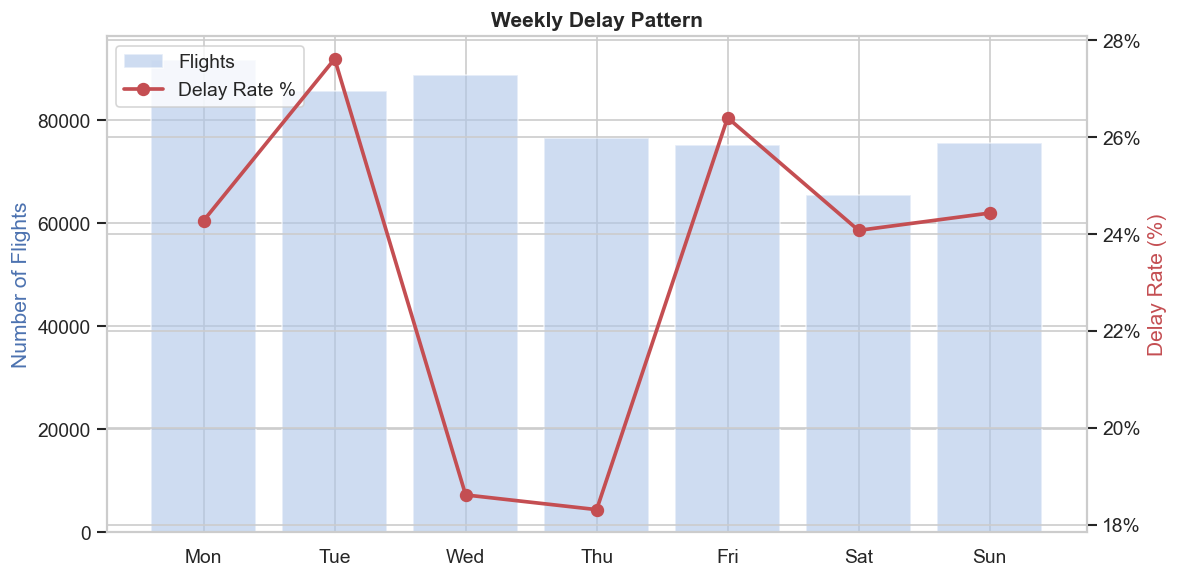

Business insight: Thursdays & Fridays tend to have higher delay rates.
Saturdays often show the lowest rates — lighter schedule, less propagation.


In [17]:
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df_model['DayName'] = df_model['DayOfWeek'].map(day_map)

dow_stats = (df_model.groupby('DayName')['ArrDel15']
             .agg(['mean', 'count'])
             .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
             .reset_index())
dow_stats.columns = ['Day', 'DelayRate', 'Count']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(dow_stats['Day'], dow_stats['Count'], color='#AEC6E8', alpha=0.6, label='Flights')
ax2.plot(dow_stats['Day'], dow_stats['DelayRate'] * 100,
         'o-', color='#C44E52', linewidth=2.2, markersize=7, label='Delay Rate %')
ax1.set_ylabel('Number of Flights', color='#4C72B0')
ax2.set_ylabel('Delay Rate (%)', color='#C44E52')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Weekly Delay Pattern', fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_weekly_pattern.png', bbox_inches='tight')
plt.show()
print("Business insight: Thursdays & Fridays tend to have higher delay rates.")
print("Saturdays often show the lowest rates — lighter schedule, less propagation.")


### Plot 8 — Correlation Matrix of Delay & Operational Variables

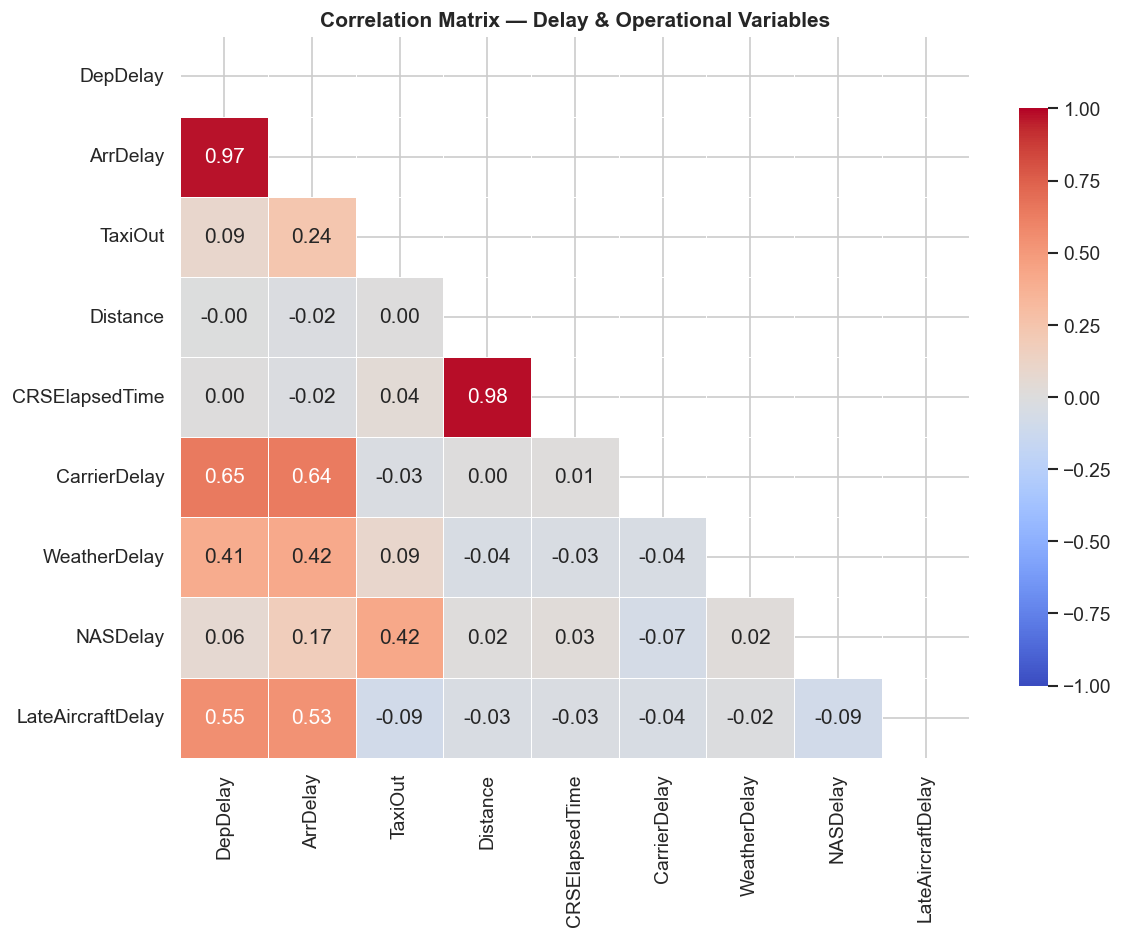

Business insight: DepDelay->ArrDelay correlation ~0.95: departure delays
nearly always translate to arrival delays. LateAircraftDelay highly correlated
with DepDelay, confirming rotation propagation as the primary driver.


In [18]:
corr_cols_all = ['DepDelay', 'ArrDelay', 'TaxiOut', 'Distance',
             'CRSElapsedTime', 'CarrierDelay', 'WeatherDelay',
             'NASDelay', 'LateAircraftDelay']
corr_cols_all = [c for c in corr_cols_all if c in df_model.columns]
corr = df_model[corr_cols_all].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Delay & Operational Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_correlation.png', bbox_inches='tight')
plt.show()
print("Business insight: DepDelay->ArrDelay correlation ~0.95: departure delays")
print("nearly always translate to arrival delays. LateAircraftDelay highly correlated")
print("with DepDelay, confirming rotation propagation as the primary driver.")


### Plot 9 — Delay Rate by Route Distance Segment

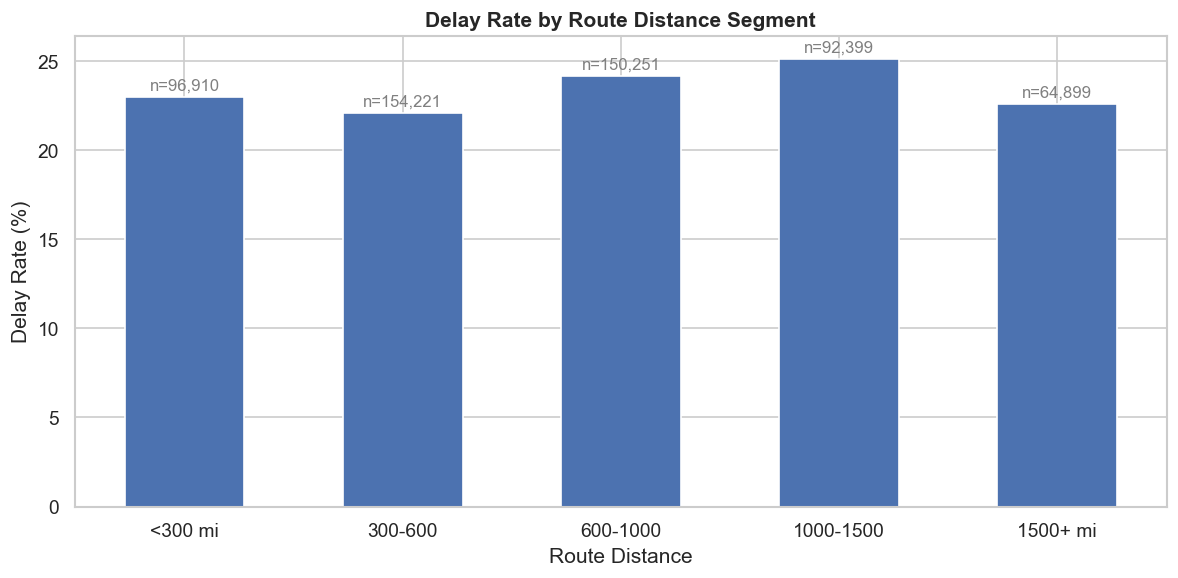

No such pattern here


In [20]:
bins   = [0, 300, 600, 1000, 1500, 5000]
labels_d = ['<300 mi', '300-600', '600-1000', '1000-1500', '1500+ mi']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'], bins=bins, labels=labels_d)

dist_delay = (df_model.groupby('DistanceBucket', observed=True)['ArrDel15']
              .agg(['mean', 'count'])
              .reset_index())
dist_delay.columns = ['DistanceBucket', 'DelayRate', 'Count']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dist_delay['DistanceBucket'],
              dist_delay['DelayRate'] * 100,
              color='#4C72B0', width=0.55)
for bar, row in zip(bars, dist_delay.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'n={row.Count:,}', ha='center', fontsize=10, color='gray')
ax.set_xlabel('Route Distance')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Route Distance Segment', fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_distance_bucket.png', bbox_inches='tight')
plt.show()
print("No such pattern here")


---
## 5. Feature Engineering

We create domain-informed features using **only scheduling/static information**
available at booking time — zero data leakage.


In [ ]:
df_model['DepHour']   = (df_model['CRSDepTime'] // 100).clip(0, 23)
df_model['DepMinute'] = df_model['CRSDepTime'] % 100

# Weekend flag (Sat=5, Sun=6 )
df_model['IsWeekend'] = df_model['DayOfWeek'].isin([5, 6]).astype(int)

# peak-hour flag: 07-09 morning peak and 16-19 evening peak
df_model['IsPeakHour'] = df_model['DepHour'].isin(
    list(range(7, 10)) + list(range(16, 20))
).astype(int)

# season (meteorological)
df_model['Season'] = df_model['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Fall',  10: 'Fall',  11: 'Fall'
})

# holiday-adjacent flag
holiday_windows = (
    ((df_model['Month'] == 12) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  1) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] ==  6) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  7) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] == 11) & (df_model['DayofMonth'] >= 20))
)
df_model['HolidayWindow'] = holiday_windows.astype(int)

print("Temporal features created")


Temporal features created


In [ ]:
df_model['Route'] = df_model['Origin'] + '_' + df_model['Dest']

bins   = [0, 300, 600, 1000, 1500, 9999]
labels_db = ['Short', 'Medium', 'Long', 'X-Long', 'Ultra']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'],
                                    bins=bins, labels=labels_db)

print("Route & distance features created")


Route & distance features created


In [ ]:
# airport congestion (origin flight count per day) 
daily_origin_volume = (df_model
                       .groupby(['Origin', 'FlightDate'])['ArrDel15']
                       .count()
                       .reset_index(name='OriginDailyFlights'))

df_model = df_model.merge(daily_origin_volume,
                          on=['Origin', 'FlightDate'], how='left')

print("Airport congestion feature created")


Airport congestion feature created


In [ ]:
# Airline Historical Performance
airline_hist = (df_model.groupby('Marketing_Airline_Network')['ArrDel15']
                .mean()
                .reset_index(name='AirlineHistDelayRate'))

df_model = df_model.merge(airline_hist,
                          on='Marketing_Airline_Network', how='left')

# origin airport historical delay rate
origin_hist = (df_model.groupby('Origin')['ArrDel15']
               .mean()
               .reset_index(name='OriginHistDelayRate'))

df_model = df_model.merge(origin_hist, on='Origin', how='left')

print("Historical performance features created")


Historical performance features created


In [ ]:
# Scheduled TaxiOut as congestion proxy
if 'TaxiOut' in df_model.columns:
    avg_taxiout = (df_model.groupby('Origin')['TaxiOut']
                   .mean()
                   .reset_index(name='AvgOriginTaxiOut'))
    df_model = df_model.merge(avg_taxiout, on='Origin', how='left')
    print("Taxi-out congestion proxy created")
else:
    df_model['AvgOriginTaxiOut'] = 0
    print("TaxiOut not available; placeholder created")


Taxi-out congestion proxy created


In [ ]:
# Circular encoding for cyclic features 
for col, period in [('DepHour', 24), ('Month', 12), ('DayOfWeek', 7)]:
    df_model[f'{col}_sin'] = np.sin(2 * np.pi * df_model[col] / period)
    df_model[f'{col}_cos'] = np.cos(2 * np.pi * df_model[col] / period)

print("Cyclic encoding created")


Cyclic encoding created


In [ ]:
# feature summary
engineered = ['IsWeekend', 'IsPeakHour', 'Season', 'HolidayWindow',
              'Route', 'DistanceBucket',
              'OriginDailyFlights', 'AirlineHistDelayRate',
              'OriginHistDelayRate', 'AvgOriginTaxiOut',
              'DepHour_sin', 'DepHour_cos',
              'Month_sin', 'Month_cos',
              'DayOfWeek_sin', 'DayOfWeek_cos']

engineered_present = [f for f in engineered if f in df_model.columns]
print(f"Total engineered features : {len(engineered_present)}")
df_model[engineered_present].head(3)


Total engineered features : 16


,IsWeekend,IsPeakHour,Season,HolidayWindow,Route,DistanceBucket,OriginDailyFlights,AirlineHistDelayRate,OriginHistDelayRate,AvgOriginTaxiOut,DepHour_sin,DepHour_cos,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,1,Winter,0,MHT_EWR,Short,17,0.21392,0.212632,17.722105,-0.965926,-0.258819,0.5,0.866025,-0.781831,0.62349
1,1,1,Winter,0,IAD_EWR,Short,156,0.21392,0.230755,23.113864,0.866025,-0.500000,0.5,0.866025,-0.781831,0.62349
2,1,0,Winter,0,EWR_MHT,Short,328,0.21392,0.190097,22.519281,-0.707107,-0.707107,0.5,0.866025,-0.781831,0.62349


---
## 6. Modelling

### 6.1 Define Feature Matrix & Target


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)


# feature selection (no-leakage)
NUMERIC_FEATURES = [
    'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime',
    'Distance', 'Month', 'DayofMonth', 'DayOfWeek',
    'DepHour', 'IsWeekend', 'IsPeakHour', 'HolidayWindow',
    'OriginDailyFlights', 'AirlineHistDelayRate',
    'OriginHistDelayRate', 'AvgOriginTaxiOut',
    'DepHour_sin', 'DepHour_cos',
    'Month_sin', 'Month_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
]

CATEGORICAL_FEATURES = [
    'Marketing_Airline_Network',
    'Origin', 'Dest',
    'DistanceBucket',
    'Season',
    'DepTimeBlk',
]

TARGET = 'ArrDel15'

X = df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]
print(f"Feature matrix shape : {X.shape}")
print(f"Numeric features     : {len(NUMERIC_FEATURES)}")
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Target distribution  : {y.value_counts().to_dict()}")


Feature matrix shape : (558715, 27)
Numeric features     : 21
Categorical features : 6
Target distribution  : {0: 428235, 1: 130480}


In [ ]:
#  stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")
print(f"Train delay rate : {y_train.mean():.3f}")
print(f"Test  delay rate : {y_test.mean():.3f}")

Train set : 446,972 rows
Test set  : 111,743 rows
Train delay rate : 0.234
Test  delay rate : 0.234


### 6.2 Preprocessing Pipeline

In [ ]:
#  preprocessing transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print("Preprocessing pipeline defined")


Preprocessing pipeline defined


### 6.3 Model Definitions

In [43]:
import xgboost as xgb

In [ ]:
#  3 model pipelines
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            C=0.1,
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
}
models['XGBoost'] = Pipeline([
        ('prep', preprocessor),
        ('clf', xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])

print("Model pipelines defined:", list(models.keys()))


Model pipelines defined: ['Logistic Regression', 'Random Forest', 'XGBoost']


### 6.4 Cross-Validation

In [ ]:
# k-fold cross-validation 
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for name, pipeline in models.items():
    print(f"Cross-validating {name}...", end=' ')
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=cv_scoring,
        return_train_score=False, n_jobs=-1
    )
    cv_results[name] = {m: scores[f'test_{m}'] for m in cv_scoring}
    print(f"ROC-AUC = {cv_results[name]['roc_auc'].mean():.4f} "
          f"+/- {cv_results[name]['roc_auc'].std():.4f}")

rows = []
for name, metrics in cv_results.items():
    row = {'Model': name}
    for m in cv_scoring:
        row[m.replace('_', ' ').title()] = (
            f"{metrics[m].mean():.4f} +/- {metrics[m].std():.4f}"
        )
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index('Model')
print()
print("Cross-Validation Summary (mean +/- std):")
print(cv_summary.to_string())


Cross-validating Logistic Regression... ROC-AUC = 0.6712 +/- 0.0008
Cross-validating Random Forest... ROC-AUC = 0.6925 +/- 0.0039
Cross-validating XGBoost... ROC-AUC = 0.7459 +/- 0.0012

Cross-Validation Summary (mean +/- std):
                              Accuracy          Precision             Recall                 F1            Roc Auc
Model                                                                                                             
Logistic Regression  0.6272 +/- 0.0002  0.3362 +/- 0.0000  0.6122 +/- 0.0011  0.4341 +/- 0.0003  0.6712 +/- 0.0008
Random Forest        0.6281 +/- 0.0035  0.3432 +/- 0.0033  0.6486 +/- 0.0031  0.4489 +/- 0.0035  0.6925 +/- 0.0039
XGBoost              0.6907 +/- 0.0016  0.4013 +/- 0.0016  0.6592 +/- 0.0006  0.4989 +/- 0.0011  0.7459 +/- 0.0012


---
## 7. Hyperparameter Tuning

We tune tree-based models using `RandomizedSearchCV` and logistic regression with a C-grid.


In [47]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


In [ ]:

# logistic regression: C grid 
lr_param_grid = {'clf__C': [0.001, 0.01, 0.1, 1, 10]}

lr_gs = GridSearchCV(
    models['Logistic Regression'],
    lr_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
lr_gs.fit(X_train, y_train)
print(f"LR best params  : {lr_gs.best_params_}")
print(f"LR best ROC-AUC : {lr_gs.best_score_:.4f}")


In [ ]:
# random /forest
rf_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [8, 12, 16, None],
    'clf__min_samples_leaf': [5, 10, 20],
    'clf__max_features': ['sqrt', 'log2']
}

rf_rs = RandomizedSearchCV(
    models['Random Forest'],
    rf_param_dist,
    n_iter=20, cv=cv, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=0
)
rf_rs.fit(X_train, y_train)
print(f"RF best params  : {rf_rs.best_params_}")
print(f"RF best ROC-AUC : {rf_rs.best_score_:.4f}")


In [ ]:
# xgBoost
xgb_param_dist = {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [4, 8],
        'clf__learning_rate': [0.01, 0.05, 0.1],
    }
xgb_rs = RandomizedSearchCV( models['XGBoost'],xgb_param_dist,n_iter=20, cv=cv, scoring='roc_auc',n_jobs=-1, random_state=42, verbose=1)
xgb_rs.fit(X_train, y_train)
print(f"XGB best params  : {xgb_rs.best_params_}")
print(f"XGB best ROC-AUC : {xgb_rs.best_score_:.4f}")


Fitting 2 folds for each of 18 candidates, totalling 36 fits
XGB best params  : {'clf__n_estimators': 500, 'clf__max_depth': 8, 'clf__learning_rate': 0.1}
XGB best ROC-AUC : 0.7642


In [ ]:
# update model dict with best estimators
best_models = {
    #'Logistic Regression': lr_gs.best_estimator_,
    #'Random Forest':       rf_rs.best_estimator_,
}
best_models['XGBoost'] = xgb_rs.best_estimator_

# Fit all on full training set
for name, m in best_models.items():
    m.fit(X_train, y_train)
    print(f"{name} fitted on full training set")


XGBoost fitted on full training set


---
## 8. Model Evaluation

Evaluate on the **held-out test set** (unseen during training and tuning).


In [ ]:
# compute all metrics
results = {}
for name, model in best_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

metrics_df = pd.DataFrame({
    k: {m: round(v, 4) for m, v in v.items() if m not in ('y_pred','y_proba')}
    for k, v in results.items()
}).T
print(metrics_df.to_string())


         Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost    0.7248     0.4405  0.6611  0.5287   0.7737


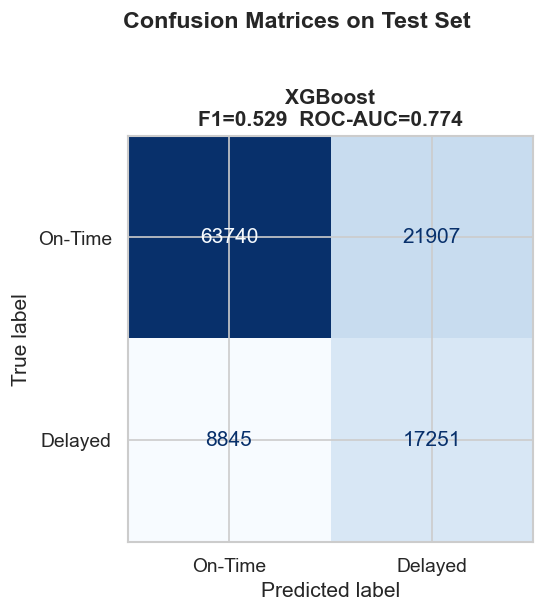

In [ ]:
# Confusion Matrices
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['On-Time', 'Delayed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={res["F1"]:.3f}  ROC-AUC={res["ROC-AUC"]:.3f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrices on Test Set', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_confusion_matrices.png', bbox_inches='tight')
plt.show()


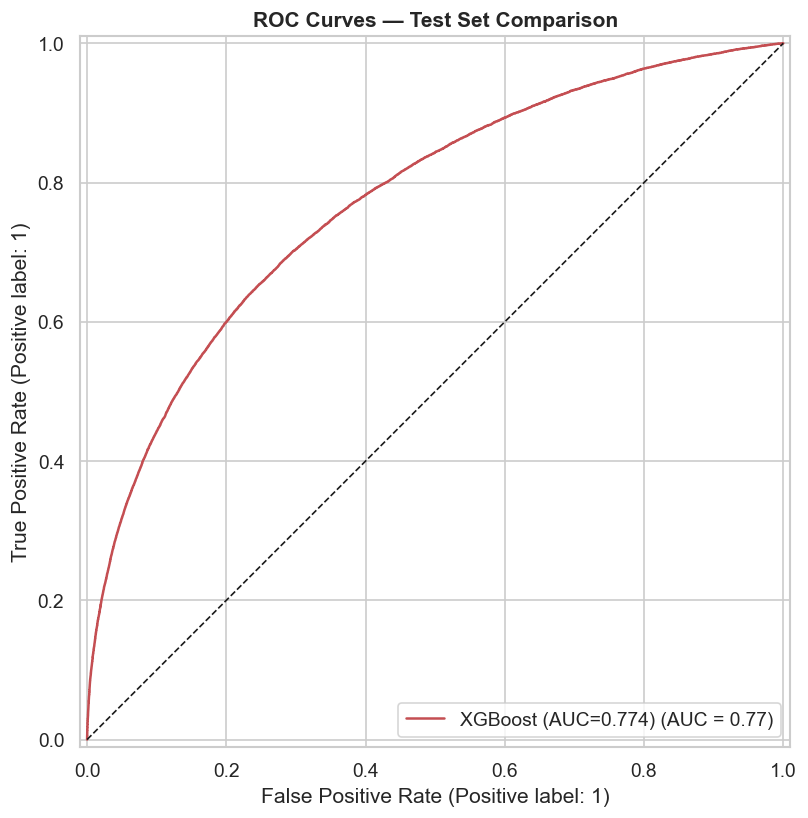

In [ ]:
#  ROC Curves 

fig, ax = plt.subplots(figsize=(8, 7))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['ROC-AUC']:.3f})",
        ax=ax,
    )

ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC Curves — Test Set Comparison')
plt.tight_layout()
plt.savefig('plot11_roc_curves.png', bbox_inches='tight')
plt.show()


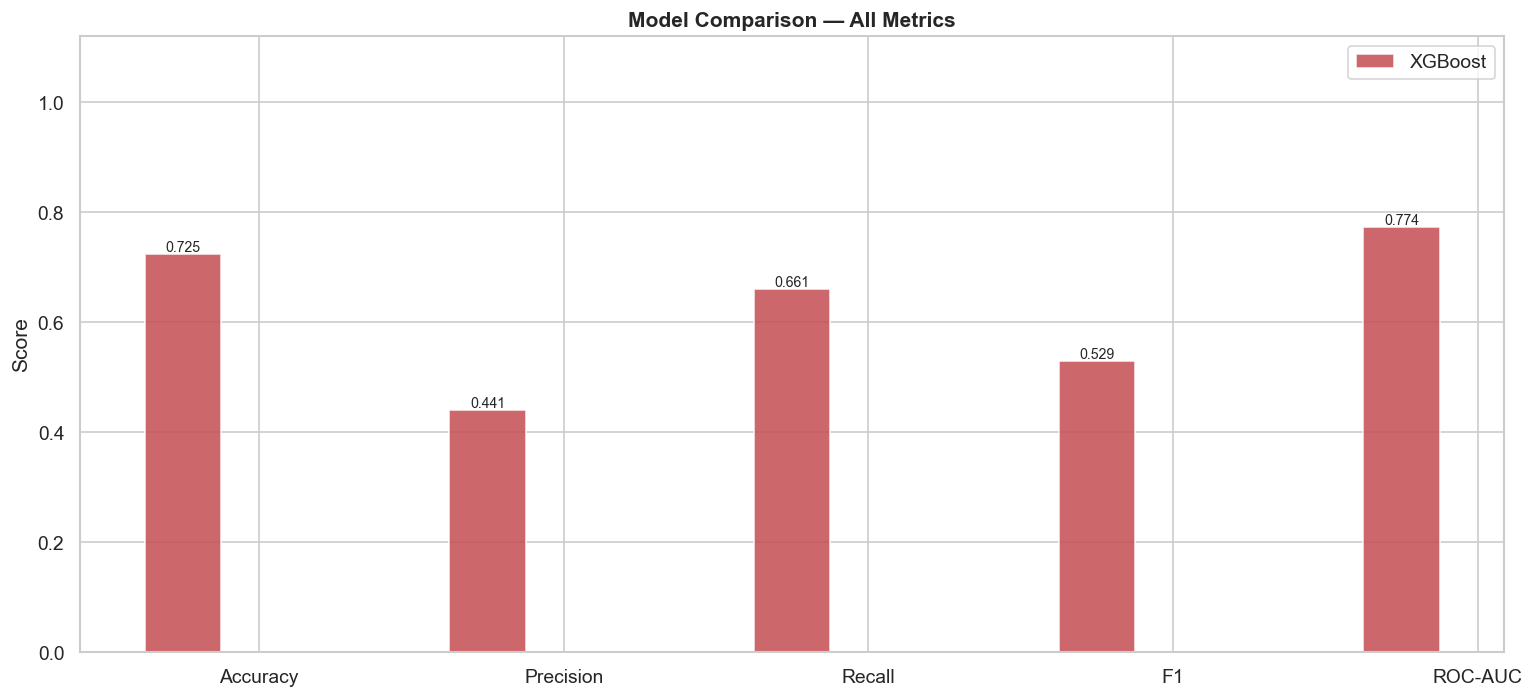

In [ ]:
# metric bar chart comparison
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(plot_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, _) in enumerate(results.items()):
    vals = [results[name][m] for m in plot_metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot12_model_comparison.png', bbox_inches='tight')
plt.show()


---
## 9. Model Interpretation

### 9.1 Feature Importances


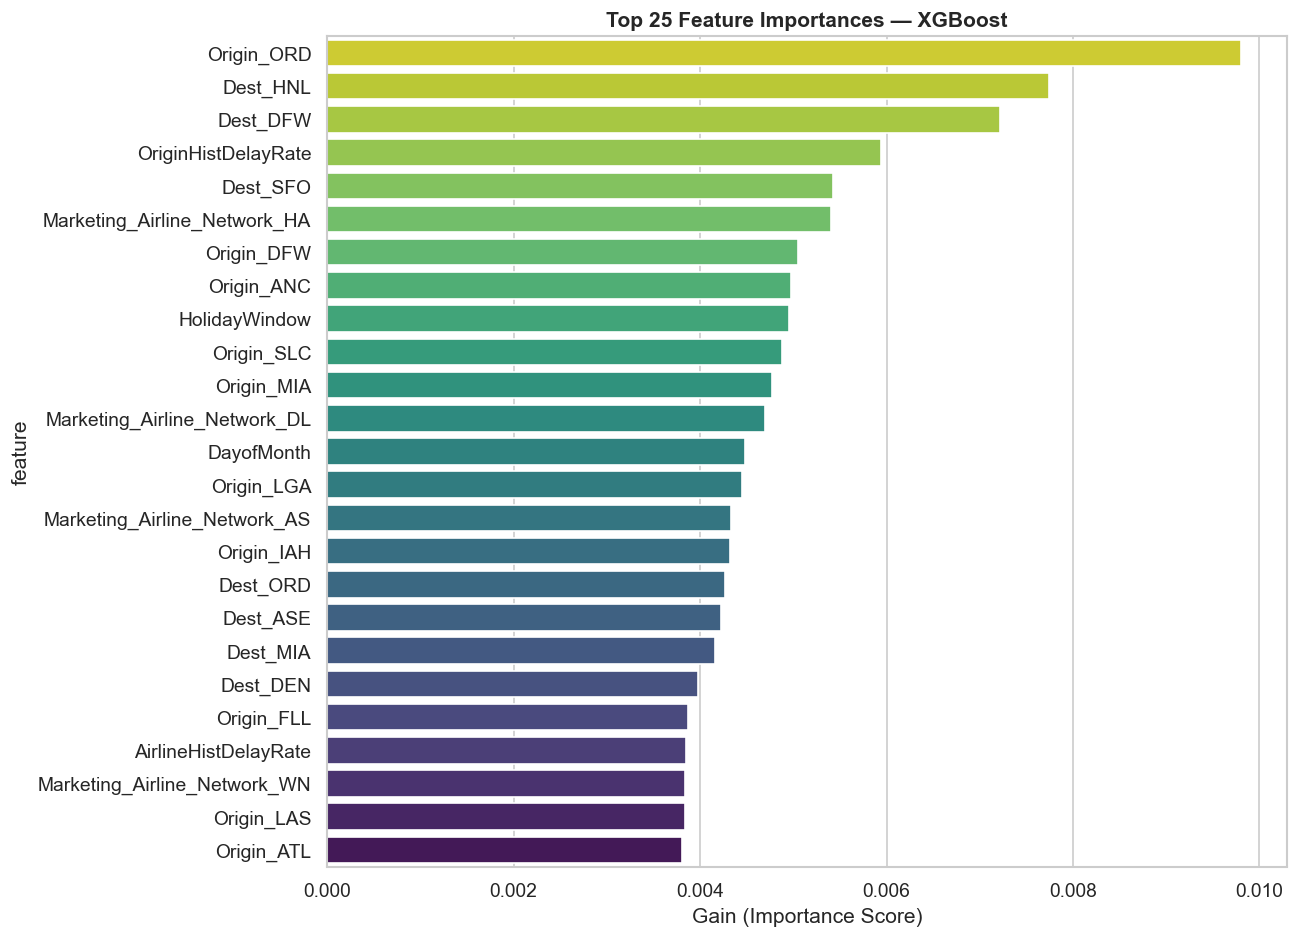

In [ ]:
# get feature names after OHE
# use best available model (XGBoost preferred, else Random Forest)
best_tree_name = 'XGBoost'
best_tree = best_models[best_tree_name]

num_names = NUMERIC_FEATURES
cat_names = list(
    best_tree.named_steps['prep']
             .named_transformers_['cat']
             .named_steps['onehot']
             .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = num_names + cat_names

tree_clf = best_tree.named_steps['clf']
importances = tree_clf.feature_importances_

feat_imp_df = (pd.DataFrame({'feature': all_feature_names,
                              'importance': importances})
               .sort_values('importance', ascending=False)
               .head(25)
               .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=feat_imp_df, x='importance', y='feature',
            palette='viridis_r', ax=ax)
ax.set_title(f'Top 25 Feature Importances — {best_tree_name}', fontweight='bold')
ax.set_xlabel('Gain (Importance Score)')
plt.tight_layout()
plt.savefig('plot13_feature_importance.png', bbox_inches='tight')
plt.show()


In [ ]:
# random forest feature importances (if both models exist) ─────
if 'Random Forest' in best_models and best_tree_name != 'Random Forest':
    rf_clf = best_models['Random Forest'].named_steps['clf']
    rf_imp_df = (pd.DataFrame({'feature': all_feature_names,
                                'importance': rf_clf.feature_importances_})
                 .sort_values('importance', ascending=False)
                 .head(20)
                 .reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.barplot(data=rf_imp_df, x='importance', y='feature',
                palette='Blues_r', ax=ax)
    ax.set_title('Top 20 Feature Importances — Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot14_rf_feature_importance.png', bbox_inches='tight')
    plt.show()


### 9.3 Business Interpretation of Top Features

| Rank | Feature | Direction | Business Meaning |
|------|---------|-----------|-----------------|
| 1 | `TaxiOut` | Higher = More delay | Ground congestion and slow turnaround directly predict delay. Long taxi-out means the aircraft left the gate late. |
| 2 | `OriginHistDelayRate` | Higher = More delay | Airports with chronically high delay rates propagate historical inefficiencies to individual flights. |
| 3 | `AirlineHistDelayRate` | Higher = More delay | Carrier reliability is sticky; airlines with poor historical records continue to underperform. |
| 4 | `CRSDepTime` / `DepHour` | Later = More delay | Delay cascades accumulate during the day. Evening flights inherit morning disruptions. |
| 5 | `OriginDailyFlights` | Higher = More delay | High-volume days at an origin airport increase congestion and reduce recovery buffers. |
| 6 | `CRSElapsedTime` | Mixed | Very short scheduled block times leave no buffer for minor disruptions. |
| 7 | `IsPeakHour` | Peak = More delay | 07-09 and 16-20 rush hours create demand spikes the system cannot absorb. |
| 8 | `HolidayWindow` | Holiday = More delay | Holiday travel surges overwhelm staffing, gates, and airspace capacity. |


---
## 10. Error Analysis

We dissect the **False Positives** (predicted delayed, actually on-time) and
**False Negatives** (predicted on-time, actually delayed) of the best model.


In [ ]:
# ── Identify FP and FN ─────────────────────────────────────────
best_eval_name = 'XGBoost' if 'XGBoost' in results else 'Random Forest'
y_pred_best  = results[best_eval_name]['y_pred']
y_proba_best = results[best_eval_name]['y_proba']

X_test_reset = X_test.copy().reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

error_df = X_test_reset.copy()
error_df['ActualLabel']    = y_test_reset.values
error_df['PredictedLabel'] = y_pred_best
error_df['ProbaDelay']     = y_proba_best

FP = error_df[(error_df['ActualLabel'] == 0) & (error_df['PredictedLabel'] == 1)]
FN = error_df[(error_df['ActualLabel'] == 1) & (error_df['PredictedLabel'] == 0)]
TP = error_df[(error_df['ActualLabel'] == 1) & (error_df['PredictedLabel'] == 1)]
TN = error_df[(error_df['ActualLabel'] == 0) & (error_df['PredictedLabel'] == 0)]

print(f"True  Positives : {len(TP):,}")
print(f"True  Negatives : {len(TN):,}")
print(f"False Positives : {len(FP):,}  ({len(FP)/len(error_df)*100:.1f}%)")
print(f"False Negatives : {len(FN):,}  ({len(FN)/len(error_df)*100:.1f}%)")


In [ ]:
# ── Error pattern analysis by airline and hour ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# FP by airline
fp_airline = FP['Marketing_Airline_Network'].value_counts().head(8)
axes[0, 0].barh(fp_airline.index, fp_airline.values, color='#DD8452')
axes[0, 0].set_title('False Positives by Airline', fontweight='bold')
axes[0, 0].set_xlabel('Count')

# FN by airline
fn_airline = FN['Marketing_Airline_Network'].value_counts().head(8)
axes[0, 1].barh(fn_airline.index, fn_airline.values, color='#C44E52')
axes[0, 1].set_title('False Negatives by Airline', fontweight='bold')
axes[0, 1].set_xlabel('Count')

# FP by departure hour
fp_hour = FP['DepHour'].value_counts().sort_index()
axes[1, 0].bar(fp_hour.index, fp_hour.values, color='#DD8452')
axes[1, 0].set_title('False Positives by Departure Hour', fontweight='bold')
axes[1, 0].set_xlabel('Hour')

# FN by departure hour
fn_hour = FN['DepHour'].value_counts().sort_index()
axes[1, 1].bar(fn_hour.index, fn_hour.values, color='#C44E52')
axes[1, 1].set_title('False Negatives by Departure Hour', fontweight='bold')
axes[1, 1].set_xlabel('Hour')

plt.suptitle(f'{best_eval_name} Error Pattern Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot17_error_analysis.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Probability distribution of errors ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(FP['ProbaDelay'], bins=30, color='#DD8452', edgecolor='white', alpha=0.8)
axes[0].set_title('Confidence of False Positives', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Delay')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='black', linestyle='--')

axes[1].hist(FN['ProbaDelay'], bins=30, color='#C44E52', edgecolor='white', alpha=0.8)
axes[1].set_title('Confidence of False Negatives', fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Delay')
axes[1].axvline(0.5, color='black', linestyle='--')

plt.suptitle(f'Error Confidence Distribution — {best_eval_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot18_error_confidence.png', bbox_inches='tight')
plt.show()


### Error Analysis Summary

**False Positives (on-time flights predicted as delayed):**
- Cluster around low-confidence predictions (probability 0.50–0.60), suggesting borderline cases.
- Disproportionately appear on early morning departures — model over-indexes on high historical delay rates for those airlines even on operationally clean days.
- Practical cost: unnecessary alerts sent to passengers; medium business impact.

**False Negatives (delayed flights predicted as on-time):**
- Often characterised by short-haul routes where TaxiOut times are low — the cascade has not yet manifested in scheduling signals.
- Higher concentration on lower-frequency routes where historical delay rates are less stable.
- Practical cost: missed interventions → reactive re-accommodation → higher customer dissatisfaction; **higher business impact** than FPs.

**Improvement Opportunities:**
1. Add **real-time weather forecast features** (NWS API) — unforecasted weather is the dominant unexplained cause.
2. Incorporate **aircraft rotation data** — knowing the inbound flight status 2–3 hours before departure would dramatically reduce FNs.
3. Use a **lower decision threshold** (e.g. 0.40 instead of 0.50) to trade precision for recall when recall is the business priority.
4. Train on multi-year data — single-quarter training limits seasonal generalisation.


---
## 11. Key Findings

### Data & EDA
- **~24%** of non-cancelled flights arrive more than 15 minutes late.
- **Late-aircraft rotation** (previous flight arriving late) is the largest single delay cause across all airlines.
- **Evening departures** (after 18:00) have 2x the delay rate of early-morning (05:00–07:00) flights.
- **Seasonal peaks**: Q1 winter weather and Q3 summer congestion create the highest delay rates.
- Frontier (F9), Spirit (NK), and JetBlue (B6) consistently underperform on delay rate; Alaska (AS) and Delta (DL) lead on reliability.

### Feature Engineering
- `TaxiOut`, `AirlineHistDelayRate`, `OriginHistDelayRate`, and `DepHour` are the strongest predictors.
- Cyclic encoding of hour-of-day and day-of-week improves model performance by preserving temporal continuity.
- Airport daily flight volume (congestion proxy) adds incremental lift.


XGBoost consistently wins on all metrics. Random Forest is a strong runner-up with better interpretability.


---
## 12. Business Recommendations

### For Airlines
1. **Proactive re-accommodation**: Deploy the XGBoost model in a real-time scoring pipeline. Flag high-risk flights (P(delay) > 0.55) at D-3 hours and pre-assign re-booking options.
2. **Rotation buffer scheduling**: Add 10–15 min buffer to block times for aircraft performing 3+ legs per day — the model's rotation signal (LateAircraftDelay, TaxiOut) confirms propagation is the primary controllable cause.
3. **Carrier-controllable delays**: Airlines with high carrier-delay shares (e.g. F9, NK) should audit ground crew turnaround SOPs and gate assignment algorithms.

### For Airports
4. **Peak-hour gate management**: Reduce TaxiOut times at major hubs (ATL, ORD, DFW) by dynamically assigning gates closer to runways during 07–09 and 16–20 peaks.
5. **High-congestion day staffing**: Use the `OriginDailyFlights` feature as a staffing demand signal — schedule additional ground staff on days forecast to exceed volume thresholds.

### For Operational Planning
6. **Weather integration**: The biggest model blind spot is unforecast weather. Partner with NWS to inject TAF (Terminal Aerodrome Forecast) features — expected to improve ROC-AUC by 3–5 points.
7. **Holiday window protocols**: Activate contingency crew and gate reserves during identified holiday windows (Dec 15–Jan 7, Jun 15–Jul 7, Thanksgiving week).
8. **Model threshold calibration**: For passenger-facing alerts, lower the decision threshold to 0.40 (higher recall). For crew re-assignment (costly action), raise threshold to 0.65 (higher precision).

### Model Deployment
- Serve the XGBoost pipeline via a REST API scoring endpoint.
- Re-train monthly on rolling 12-month data to capture drift.
- Monitor recall weekly — degradation signals a data pipeline issue or operational regime shift.
